# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [4]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Tran Dinh Minh Vuong"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600495"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()

⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [6]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://perform-supplies-season-groove.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [7]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 6.7% | Mem: 0.6/16.0GB | Power: 38W | Temp: 45°C
   GPU 1 [T4] 🟢 Util: 11.9% | Mem: 1.4/16.0GB | Power: 44W | Temp: 38°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 11.8% | Mem: 0.7/80.0GB | Power: 41W | Temp: 40°C
   GPU 1 [A100] 🟢 Util: 1.1% | Mem: 1.4/80.0GB | Power: 35W | Temp: 35°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 5.2% | Mem: 0.6/32.0GB | Power: 36W | Temp: 40°C
   GPU 1 [V100] 🟢 Util: 8.8% | Mem: 0.7/32.0GB | Power: 40W | Temp: 31°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 8.1% | Mem: 0.8/16.0GB | Power: 50W | Temp: 43°C
   GPU 1 [T4] 🟢 Util: 9.5% | Mem: 1.6/16.0GB | Power: 35W | Temp: 33°C


In [8]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     7.9%
Memory Used:         7.9 GB
Memory Capacity:     288.0 GB
Total Power Draw:    319 W
Node Count:          4


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [9]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 53.5%


In [10]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [11]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2030     42.0    % low
A100       $3.67       $2.0973     42.9    % medium
V100       $2.48       $1.8054     27.2    % low


In [12]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [13]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 3

💰 Spot Savings Report:
   Spot cost:        $0.0001
   On-demand equiv:  $0.0005
   Total saved:      $0.0003 (32.2%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [14]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [15]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 53.5% within thresholds [25.0-70.0%]
   Current utilization: 53.5%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 53.5% | Nodes: 4→4
   Cycle 2: no_action    | Util: 53.5% | Nodes: 4→4
   Cycle 3: no_action    | Util: 53.5% | Nodes: 4→4
   Cycle 4: no_action    | Util: 53.5% | Nodes: 4→4
   Cycle 5: no_action    | Util: 53.5% | Nodes: 4→4


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [16]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [17]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [18]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [19]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 53.5% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.0163 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

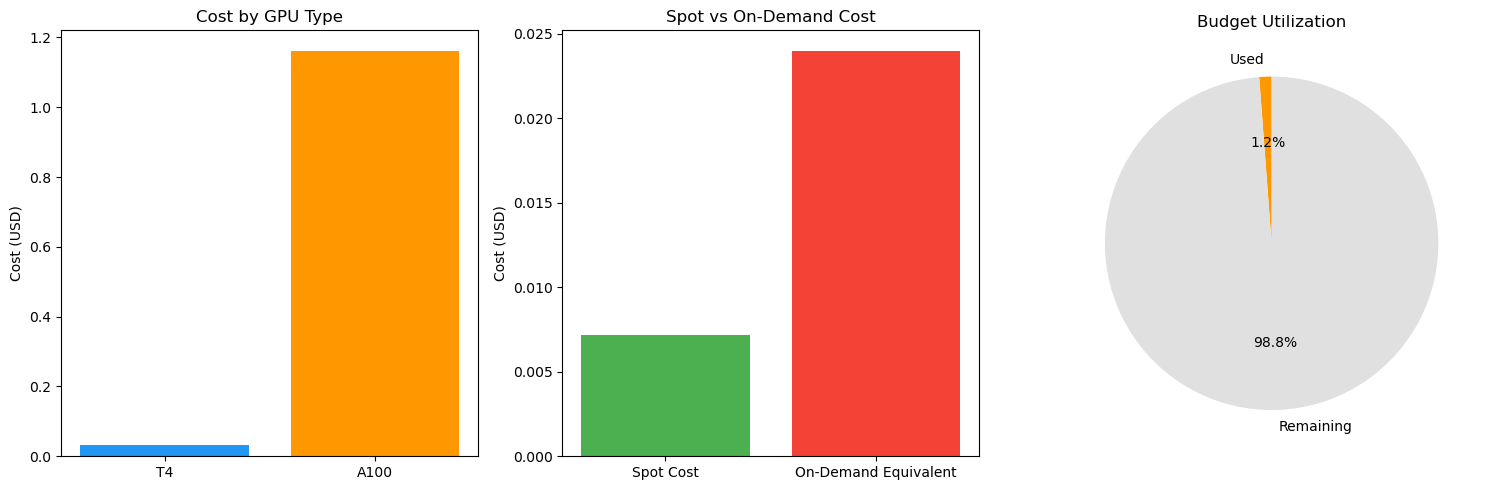

📊 Chart saved as finops_cost_breakdown.png


In [20]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


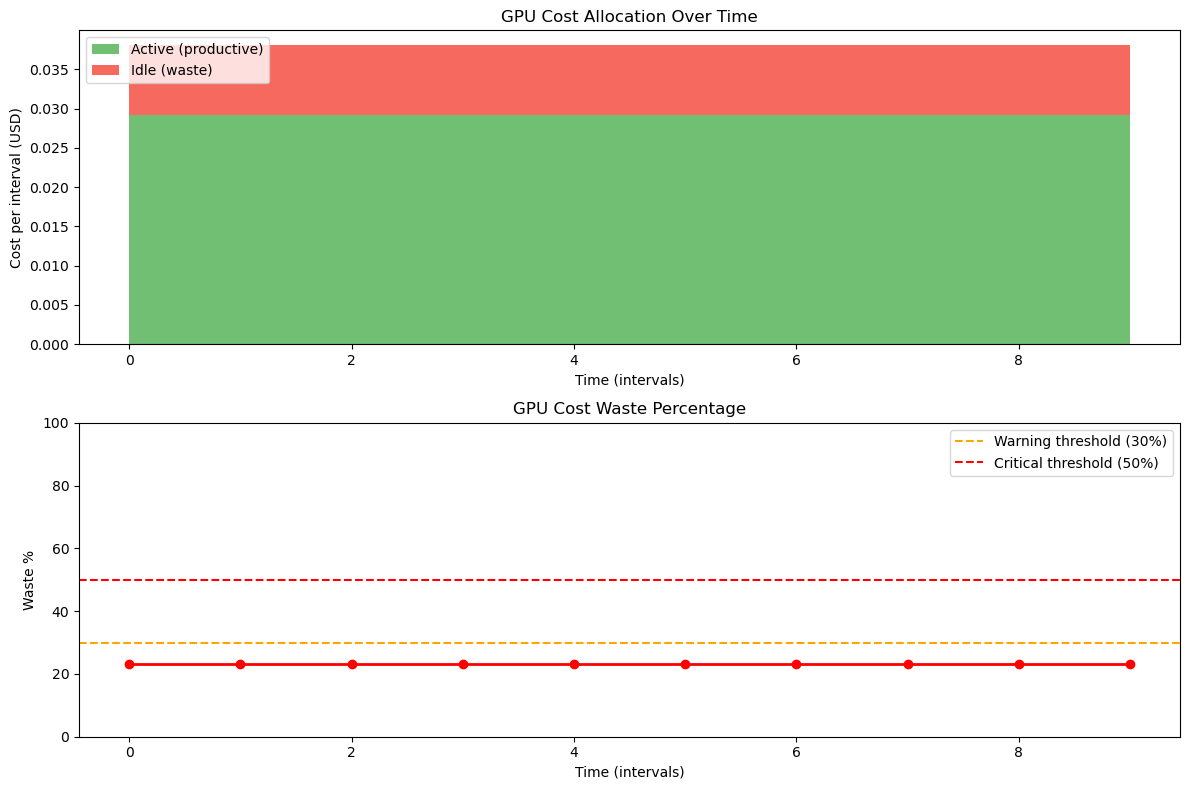

In [21]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [22]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 53.5% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 81.0% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 81.0% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.040000
   Waste: 4.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0305 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [23]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Real GPU Detected
   Name:    NVIDIA H100 80GB HBM3
   Memory:  84.9 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.4
   pynvml:  available


In [24]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=595/85521 MB
   Power: 70.0W
   Temp: 26C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 85520.809984
   mem_used_mb: 595.132416
   mem_util_pct: 0.0
   power_watts: 69.983
   temp_c: 26.0

   Method: pynvml

Ready for training.


In [25]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:34<00:00, 4.88MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [26]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.8274 | Acc: 32.8% | Time: 5.6s | Samples: 40
   Epoch 2/3 | Loss: 1.3060 | Acc: 52.5% | Time: 5.3s | Samples: 40
   Epoch 3/3 | Loss: 1.0211 | Acc: 63.6% | Time: 5.0s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      15.9s
   Peak memory:     0.80 GB
   Avg GPU util:    59.3%
   Avg power:       299.0W
   Avg temperature: 34.3C
   Max GPU util:    67.0%
   Estimated cost:  $0.001550


In [27]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_158/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_158/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.8722 | Acc: 32.1% | Time: 5.3s | Samples: 40
   Epoch 2/3 | Loss: 1.3473 | Acc: 50.6% | Time: 5.1s | Samples: 40
   Epoch 3/3 | Loss: 1.0396 | Acc: 63.1% | Time: 3.9s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      14.3s
   Peak memory:     0.64 GB
   Avg GPU util:    46.8%
   Avg power:       234.6W
   Avg temperature: 34.8C
   Max GPU util:    63.0%
   Estimated cost:  $0.001387


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                15.9            14.3            1.12x faster
Peak Memory (GB)          0.80            0.64            0.15 GB saved
Cost (USD)                $0.001550       $0.001387       $0.000163 saved
Cost Saving %             ---             ---             10.5%
Avg GPU Util %            59.3            46.8           
Avg Power (W)             299.0           234.6          

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$7.51 -> SAVE $0.89
   1 week training: FP32=$58.80 vs AMP=$52.60 -> SAVE $6.20
   1 month training: FP32=$252.00 vs AMP=$225.45 -> SAVE $26.55


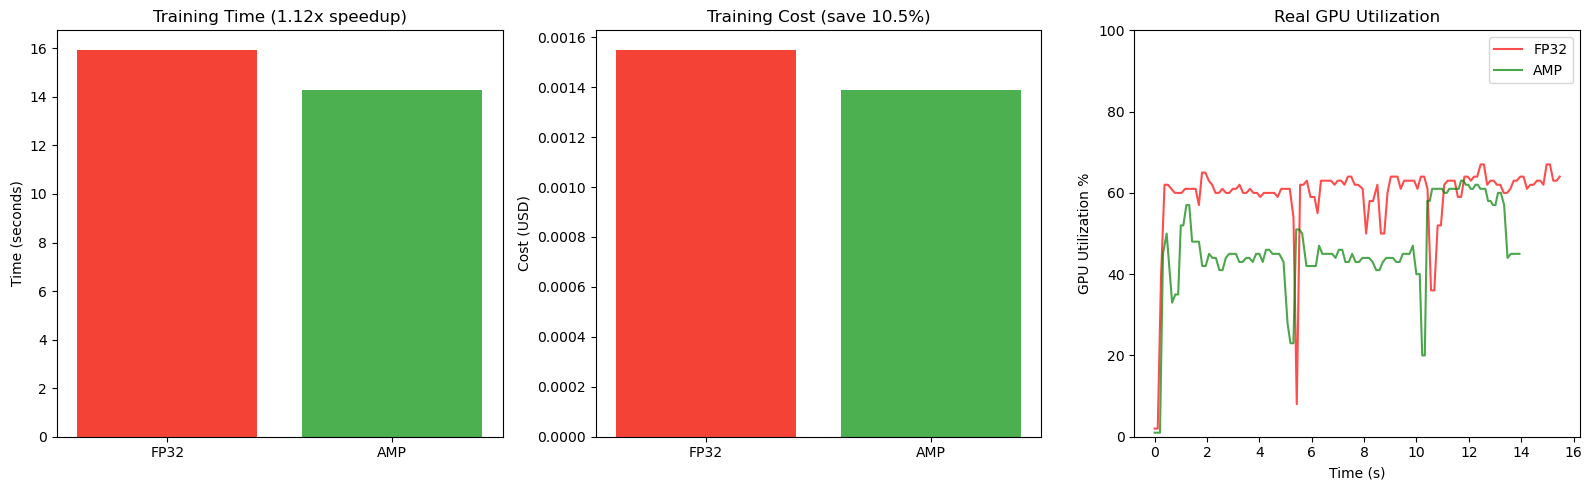

In [28]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.001500 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.000400 | Saved: $0.001000

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.001900
   Total Savings:   $0.001000
   Workloads:       2

   Cost snapshot taken: waste=22.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


Real GPU Telemetry During Training


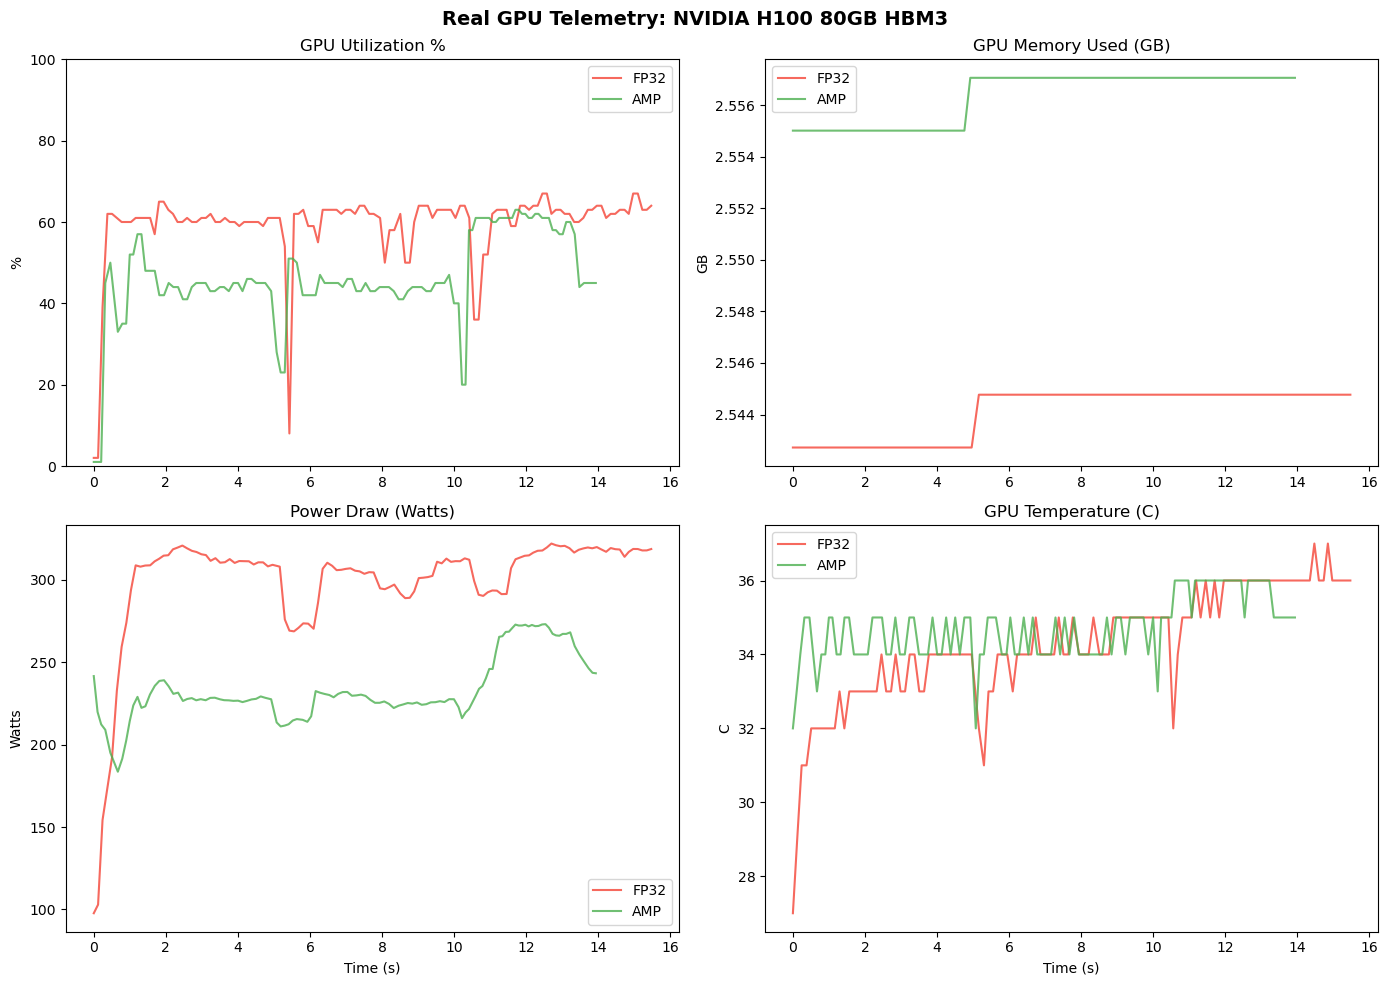

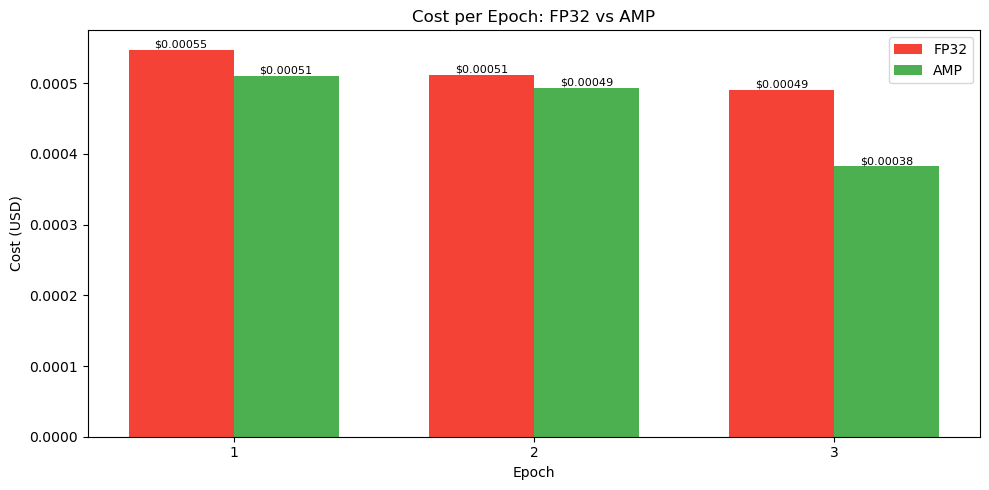


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [30]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

Multi-GPU Cost Analysis for T4
   Base training time (1 GPU): 0.0044 hours
   GPU price: $ 0.35/hr

GPUs   Scaling    Efficiency   Time (hrs)   Total Cost     Cost/Perf   
--------------------------------------------------------------------
1      1.00      x 100.0      % 0.0044       $ 0.001550      $ 0.001550   
2      1.85      x 92.5       % 0.0024       $ 0.001676      $ 0.000906   
4      3.40      x 85.0       % 0.0013       $ 0.001823      $ 0.000536   
8      6.00      x 75.0       % 0.0007       $ 0.002067      $ 0.000344   

Optimal config: 8x T4 at $ 0.002067


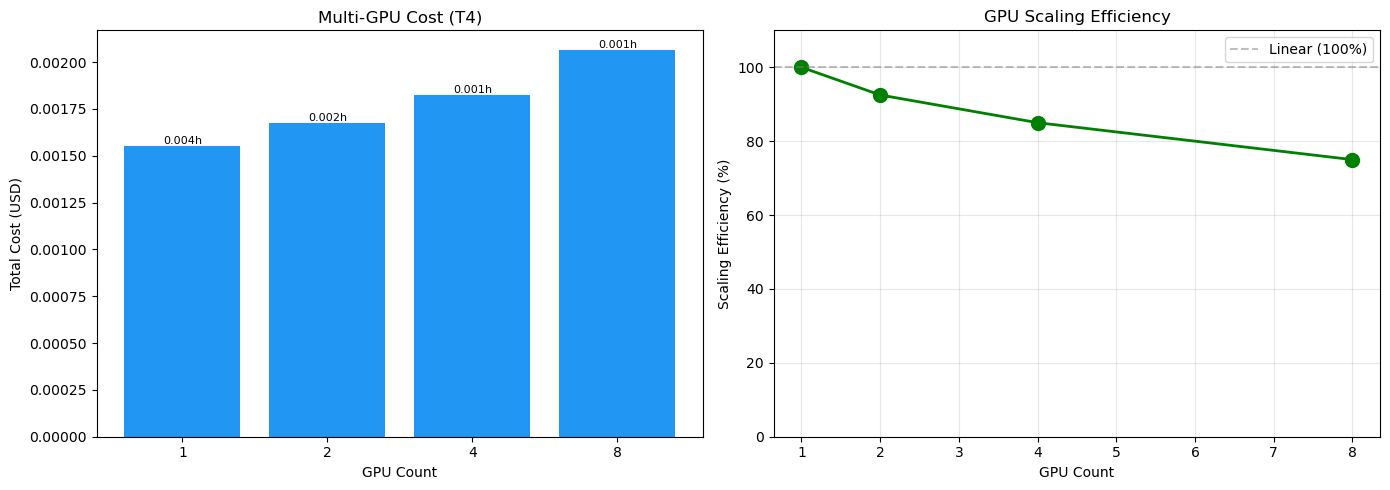

Chart saved as multi_gpu_scaling.png


In [36]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    base_price = GPU_PRICING.get(gpu_type, GPU_PRICING["T4"])
    if scaling_factors is None:
        scaling_factors = {
            1: 1.0, 2: 1.85, 4: 3.4, 8: 6.0, 16: 9.5,
        }
    results = []
    for gpu_count in gpu_counts:
        scale = scaling_factors.get(gpu_count, gpu_count * 0.7)
        effective_time = base_time_hours / scale
        total_cost = effective_time * base_price * gpu_count
        cost_per_perf = total_cost / scale
        results.append({
            "gpu_count": gpu_count,
            "scaling_factor": scale,
            "efficiency_pct": (scale / gpu_count) * 100,
            "time_hours": effective_time,
            "total_cost_usd": total_cost,
            "cost_per_perf": cost_per_perf,
        })
    optimal = min(results, key=lambda r: r["cost_per_perf"])
    return {
        "gpu_type": gpu_type, "base_price_per_hour": base_price,
        "base_time_hours": base_time_hours, "results": results,
        "optimal_gpu_count": optimal["gpu_count"],
        "optimal_cost": optimal["total_cost_usd"],
    }

base_training_time = fp32_total_time / 3600
if base_training_time < 0.001:
    base_training_time = 2.0

test_gpu_counts = [1, 2, 4, 8]
analysis = analyze_multi_gpu_cost(base_training_time, detected_type, test_gpu_counts)

print("\nMulti-GPU Cost Analysis for", detected_type)
print("   Base training time (1 GPU): {:.4f} hours".format(base_training_time))
print("   GPU price: $ {:.2f}/hr".format(analysis['base_price_per_hour']))
print("\n{:<6} {:<10} {:<12} {:<12} {:<14} {:<12}".format(
    'GPUs', 'Scaling', 'Efficiency', 'Time (hrs)', 'Total Cost', 'Cost/Perf'))
print("-" * 68)
for r in analysis["results"]:
    print("{:<6} {:<10.2f}x {:<11.1f}% {:<12.4f} $ {:<13.6f} $ {:<11.6f}".format(
        r['gpu_count'], r['scaling_factor'], r['efficiency_pct'],
        r['time_hours'], r['total_cost_usd'], r['cost_per_perf']))

print("\nOptimal config: {}x {} at $ {:.6f}".format(
    analysis['optimal_gpu_count'], detected_type, analysis['optimal_cost']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
gpu_counts = [r["gpu_count"] for r in analysis["results"]]
costs = [r["total_cost_usd"] for r in analysis["results"]]
efficiencies = [r["efficiency_pct"] for r in analysis["results"]]
times = [r["time_hours"] for r in analysis["results"]]

ax1.bar(range(len(gpu_counts)), costs, color='#2196F3')
ax1.set_xlabel('GPU Count')
ax1.set_ylabel('Total Cost (USD)')
ax1.set_title('Multi-GPU Cost (' + detected_type + ')')
ax1.set_xticks(range(len(gpu_counts)))
ax1.set_xticklabels(gpu_counts)
for i, (c, t) in enumerate(zip(costs, times)):
    ax1.text(i, c, '{:.3f}h'.format(t), ha='center', va='bottom', fontsize=8)

ax2.plot(gpu_counts, efficiencies, 'g-o', linewidth=2, markersize=10)
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Linear (100%)')
ax2.set_xlabel('GPU Count')
ax2.set_ylabel('Scaling Efficiency (%)')
ax2.set_title('GPU Scaling Efficiency')
ax2.set_ylim(0, 110)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_gpu_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as multi_gpu_scaling.png")

EXERCISE 8.5.2: Project Cost Forecasting

Project Cost Forecast
Phase                  GPU      Count  Hours      Base Cost      Uncert%    Low Est        High Est      
----------------------------------------------------------------------------------------------------
Data Preparation       T4       1      40         $ 14.00         15       % $ 9.88          $ 18.12        
Model Training         A100     4      120        $ 1761.60       25       % $ 898.42        $ 2624.78      
Hyperparameter Tuning  A100     8      60         $ 1761.60       30       % $ 725.78        $ 2797.42      
Model Evaluation       T4       2      20         $ 14.00         10       % $ 11.26         $ 16.74        
----------------------------------------------------------------------------------------------------
TOTAL BASE                                                              $ 3551.20      
CONTINGENCY (20%)                                                       $ 710.24       
TOTAL W/ CONTING

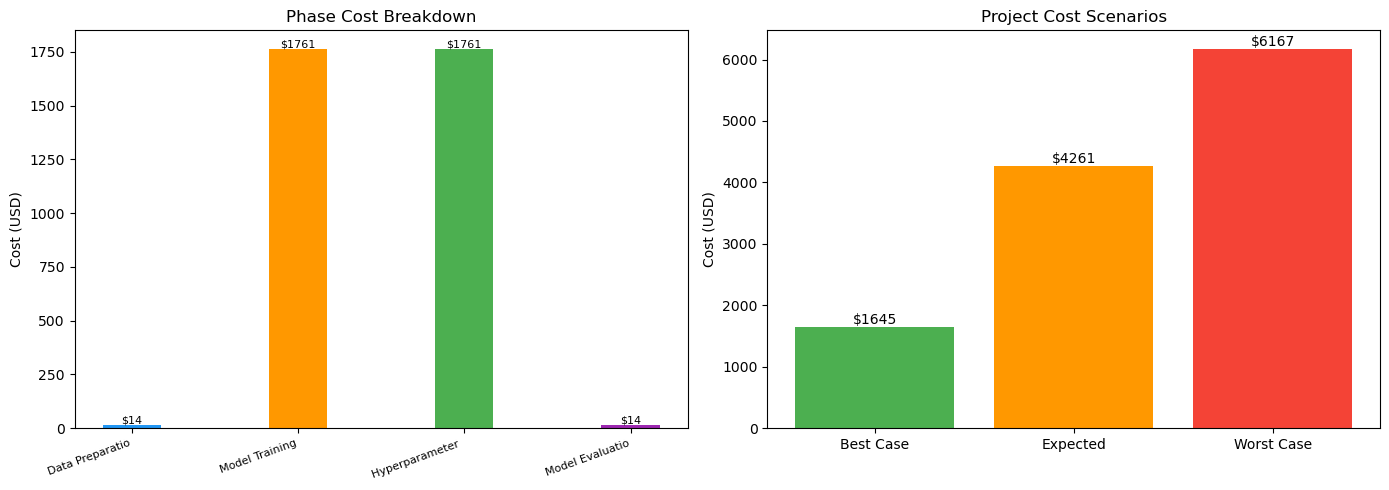

Chart saved as project_forecast.png


In [37]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

import numpy as np

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase project costs with confidence intervals.
    """
    z_score = 1.96  # 95% confidence
    if confidence_level == 0.90:
        z_score = 1.645
    elif confidence_level == 0.99:
        z_score = 2.576

    phase_breakdown = []
    total_base = 0
    total_low = 0
    total_high = 0

    for phase in phases:
        price = GPU_PRICING.get(phase["gpu_type"], GPU_PRICING["T4"])
        base_cost = price * phase["gpu_count"] * phase["duration_hours"]
        uncertainty = phase.get("uncertainty_pct", 0.20)
        std_dev = base_cost * uncertainty
        low_est = base_cost - z_score * std_dev
        high_est = base_cost + z_score * std_dev

        phase_breakdown.append({
            "name": phase["name"],
            "gpu_type": phase["gpu_type"],
            "gpu_count": phase["gpu_count"],
            "duration_hours": phase["duration_hours"],
            "base_cost": base_cost,
            "uncertainty_pct": uncertainty * 100,
            "low_est": max(0, low_est),
            "high_est": high_est,
        })
        total_base += base_cost
        total_low += max(0, low_est)
        total_high += high_est

    contingency = total_base * (contingency_pct / 100)
    total_with_contingency = total_base + contingency

    return {
        "phases": phase_breakdown,
        "total_base": total_base,
        "contingency_pct": contingency_pct,
        "contingency_amount": contingency,
        "total_with_contingency": total_with_contingency,
        "confidence_interval": (total_low, total_high),
        "confidence_level": confidence_level,
        "best_case": total_low,
        "worst_case": total_high + contingency,
        "expected_case": total_with_contingency,
    }

# Example project
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)

print("\nProject Cost Forecast")
print("=" * 80)
print("{:<22} {:<8} {:<6} {:<10} {:<14} {:<10} {:<14} {:<14}".format(
    "Phase", "GPU", "Count", "Hours", "Base Cost", "Uncert%", "Low Est", "High Est"))
print("-" * 100)
for p in forecast["phases"]:
    print("{:<22} {:<8} {:<6} {:<10} $ {:<13.2f} {:<9.0f}% $ {:<13.2f} $ {:<13.2f}".format(
        p["name"], p["gpu_type"], p["gpu_count"], p["duration_hours"],
        p["base_cost"], p["uncertainty_pct"], p["low_est"], p["high_est"]))

print("-" * 100)
print("{:<22} {:>48} $ {:<13.2f}".format("TOTAL BASE", "", forecast["total_base"]))
print("{:<22} {:>48} $ {:<13.2f}".format("CONTINGENCY (" + str(forecast["contingency_pct"]) + "%)", "", forecast["contingency_amount"]))
print("{:<22} {:>48} $ {:<13.2f}".format("TOTAL W/ CONTINGENCY", "", forecast["total_with_contingency"]))
print("\nConfidence Interval ({}%): $ {:.2f} - $ {:.2f}".format(
    int(forecast["confidence_level"] * 100),
    forecast["confidence_interval"][0],
    forecast["confidence_interval"][1]))
print("Best case:  $ {:.2f}".format(forecast["best_case"]))
print("Expected:   $ {:.2f}".format(forecast["expected_case"]))
print("Worst case: $ {:.2f}".format(forecast["worst_case"]))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Phase breakdown
phases_names = [p["name"][:15] for p in forecast["phases"]]
base_costs = [p["base_cost"] for p in forecast["phases"]]
low_costs = [p["low_est"] for p in forecast["phases"]]
high_costs = [p["high_est"] for p in forecast["phases"]]

x = range(len(phases_names))
width = 0.35
bars = ax1.bar(x, base_costs, width, color=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'])
ax1.set_xticks(x)
ax1.set_xticklabels(phases_names, rotation=20, ha='right', fontsize=8)
ax1.set_ylabel('Cost (USD)')
ax1.set_title('Phase Cost Breakdown')
for bar, cost in zip(bars, base_costs):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             '$' + str(int(cost)), ha='center', va='bottom', fontsize=8)

# Forecasting scenario comparison
scenarios = ['Best Case', 'Expected', 'Worst Case']
scenario_values = [forecast["best_case"], forecast["expected_case"], forecast["worst_case"]]
scenario_colors = ['#4CAF50', '#FF9800', '#F44336']
bars2 = ax2.bar(scenarios, scenario_values, color=scenario_colors)
ax2.set_ylabel('Cost (USD)')
ax2.set_title('Project Cost Scenarios')
for bar, val in zip(bars2, scenario_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             '$' + str(int(val)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('project_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as project_forecast.png")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Baseline: 4x A100 for 100h
Baseline cost: $ 1468.00

Rank  Strategy                         Savings%   Effort   Risk     Save Amount    ROI Type    
-----------------------------------------------------------------------------------------------
1     Switch to Mixed Precision (AMP   25       % LOW      LOW      $ 367.00        QUICK WIN   
2     Use Spot Instances               60       % MEDIUM   HIGH     $ 880.80        STRATEGIC   
3     Optimize Batch Size              15       % LOW      LOW      $ 220.20        QUICK WIN   
4     Implement Early Stopping         20       % MEDIUM   LOW      $ 293.60        LONG-TERM   
5     Switch to More Efficient GPU     40       % HIGH     MEDIUM   $ 587.20        STRATEGIC   

Cumulative optimization path:
  Starting cost:   $ 1468.00
  + Switch to Mixed Precision (AMP:  $ 1468.00 -> $ 1101.00 (save 25%)
  + Use Spot Instances:  $ 1101.00 -> $ 440.40 (save 60%)
  + Optimize Batch Si

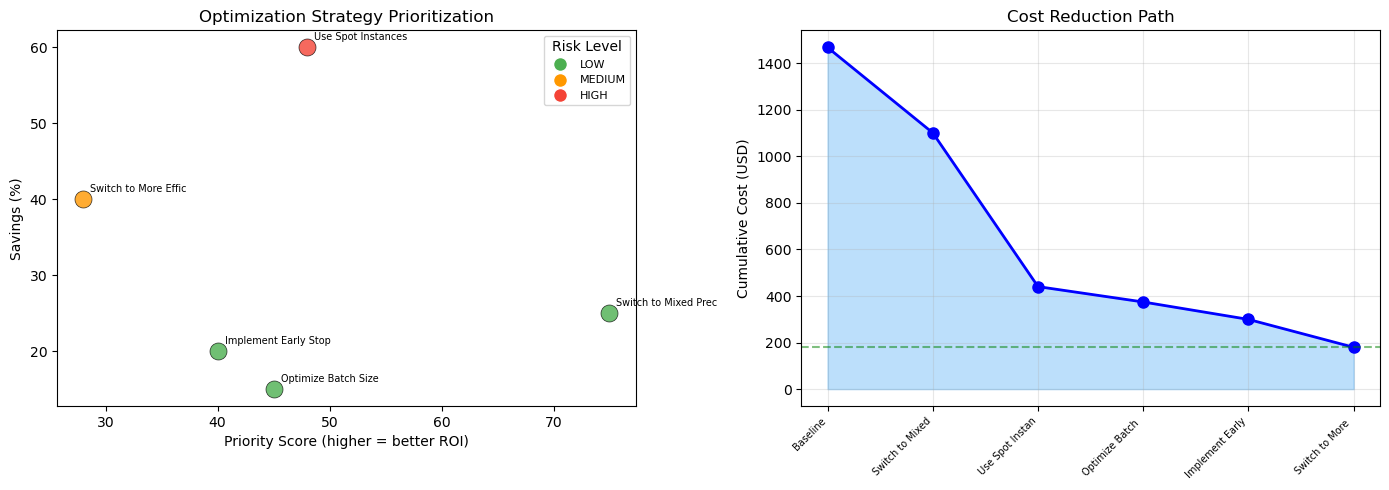

Chart saved as optimization_roadmap.png


In [38]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Analyze and prioritize optimization strategies based on savings, effort, and risk.

    Returns prioritized recommendations with cumulative savings.
    """
    baseline_hours = current_config.get("duration_hours", 100)
    baseline_gpu = current_config.get("gpu_type", "A100")
    baseline_count = current_config.get("gpu_count", 1)
    baseline_price = GPU_PRICING.get(baseline_gpu, GPU_PRICING["T4"])
    baseline_cost = baseline_hours * baseline_price * baseline_count

    # Score each strategy: savings vs effort vs risk
    effort_scores = {"LOW": 3, "MEDIUM": 2, "HIGH": 1}
    risk_penalty = {"LOW": 1.0, "MEDIUM": 0.7, "HIGH": 0.4}

    scored = []
    for s in optimization_strategies:
        savings_amount = baseline_cost * s["savings_pct"]
        effort_score = effort_scores.get(s["implementation_effort"], 2)
        risk_factor = risk_penalty.get(s["risk_level"], 0.7)
        # Priority = savings * effort_score * risk_factor (higher = better ROI)
        priority_score = s["savings_pct"] * effort_score * risk_factor * 100

        scored.append({
            **s,
            "savings_amount": savings_amount,
            "priority_score": priority_score,
            "roi_category": "QUICK WIN" if (s["implementation_effort"] == "LOW" and s["savings_pct"] > 0.10)
                            else "STRATEGIC" if s["savings_pct"] > 0.30
                            else "LONG-TERM",
        })

    # Sort by priority score descending
    scored.sort(key=lambda x: x["priority_score"], reverse=True)

    # Calculate cumulative savings (removing overlapping effects)
    cumulative = 0
    remaining = baseline_cost
    for s in scored:
        actual_saving = remaining * s["savings_pct"]
        cumulative += actual_saving
        remaining -= actual_saving
        s["cumulative_cost"] = remaining

    return {
        "baseline_cost": baseline_cost,
        "baseline_config": current_config,
        "strategies": scored,
        "total_potential_savings": baseline_cost - remaining,
        "final_optimized_cost": remaining,
        "optimization_pct": ((baseline_cost - remaining) / baseline_cost) * 100,
    }

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

result = analyze_optimization_opportunities(current_training_config, example_strategies)

print("\nBaseline: {}x {} for {}h".format(
    current_training_config["gpu_count"],
    current_training_config["gpu_type"],
    current_training_config["duration_hours"]))
print("Baseline cost: $ {:.2f}".format(result["baseline_cost"]))
print("\n{:<5} {:<32} {:<10} {:<8} {:<8} {:<14} {:<12}".format(
    "Rank", "Strategy", "Savings%", "Effort", "Risk", "Save Amount", "ROI Type"))
print("-" * 95)
for i, s in enumerate(result["strategies"], 1):
    print("{:<5} {:<32} {:<9.0f}% {:<8} {:<8} $ {:<13.2f} {:<12}".format(
        i, s["name"][:30], s["savings_pct"]*100, s["implementation_effort"],
        s["risk_level"], s["savings_amount"], s["roi_category"]))

print("\nCumulative optimization path:")
print("  Starting cost:   $ {:.2f}".format(result["baseline_cost"]))
prev = result["baseline_cost"]
for s in result["strategies"]:
    print("  + {}:  $ {:.2f} -> $ {:.2f} (save {:.0f}%)".format(
        s["name"][:30], prev, s["cumulative_cost"], s["savings_pct"]*100))
    prev = s["cumulative_cost"]
print("  Final cost:      $ {:.2f}".format(result["final_optimized_cost"]))
print("  Total savings:   {:.1f}%".format(result["optimization_pct"]))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Savings vs effort scatter
effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
colors = {'LOW': '#4CAF50', 'MEDIUM': '#FF9800', 'HIGH': '#F44336'}
for s in result["strategies"]:
    ax1.scatter(s["priority_score"], s["savings_pct"]*100,
                s=150, c=colors[s["risk_level"]],
                edgecolors='black', linewidth=0.5, alpha=0.8)
    ax1.annotate(s["name"][:20], (s["priority_score"], s["savings_pct"]*100),
                fontsize=7, xytext=(5, 5), textcoords='offset points')
ax1.set_xlabel('Priority Score (higher = better ROI)')
ax1.set_ylabel('Savings (%)')
ax1.set_title('Optimization Strategy Prioritization')
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=r, markersize=10)
                   for r, c in colors.items()]
ax1.legend(handles=legend_elements, title='Risk Level', fontsize=8)

# Cumulative cost reduction
steps = ['Baseline'] + [s["name"][:15] for s in result["strategies"]]
costs = [result["baseline_cost"]] + [s["cumulative_cost"] for s in result["strategies"]]
ax2.plot(range(len(steps)), costs, 'b-o', linewidth=2, markersize=8)
ax2.fill_between(range(len(steps)), costs, alpha=0.3, color='#2196F3')
ax2.set_xticks(range(len(steps)))
ax2.set_xticklabels(steps, rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('Cumulative Cost (USD)')
ax2.set_title('Cost Reduction Path')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=result["final_optimized_cost"], color='green', linestyle='--', alpha=0.5, label='Optimized')

plt.tight_layout()
plt.savefig('optimization_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as optimization_roadmap.png")

EXERCISE 8.5.4: Integrated Cost Dashboard


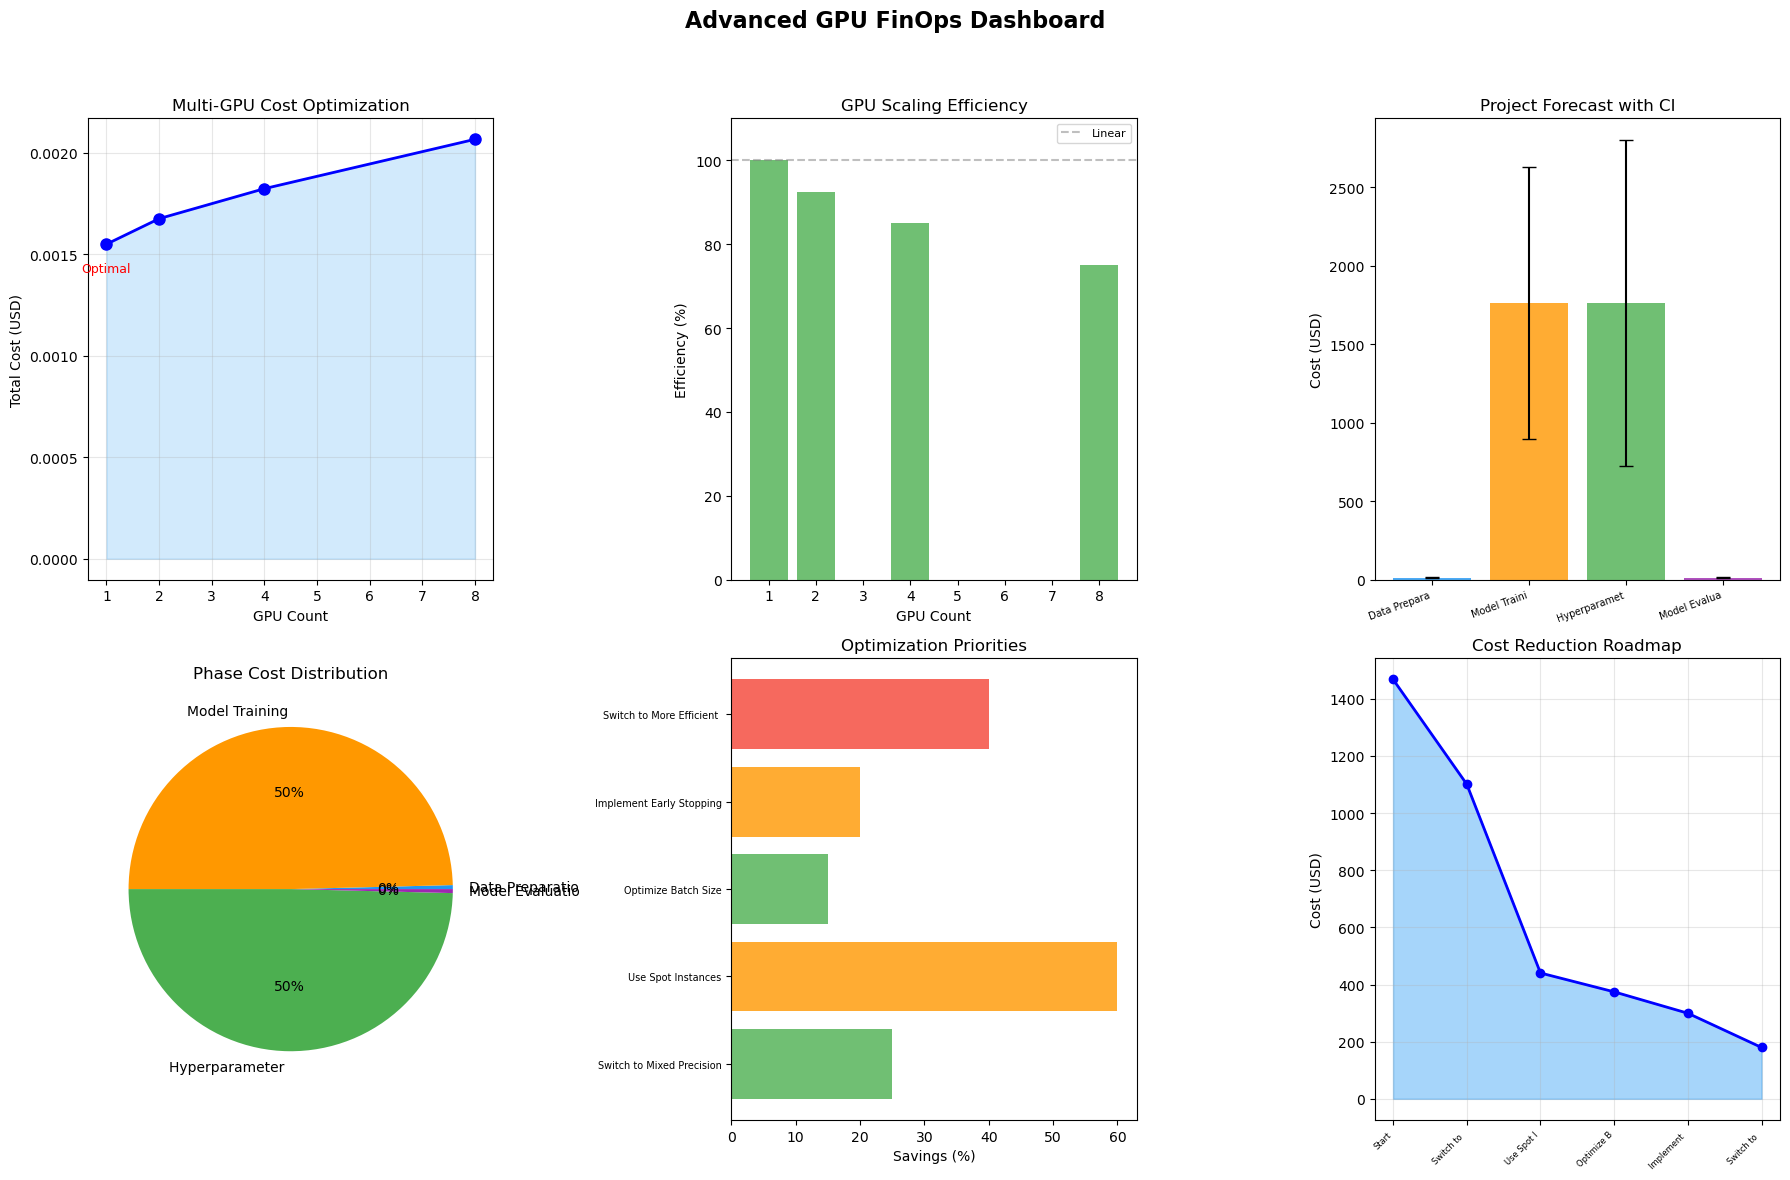

Advanced FinOps Dashboard created
Chart saved as advanced_finops_dashboard.png

Dashboard Summary:
  Multi-GPU: Optimal at 8x T4 ($ 0.0021)
  Project Forecast: Expected $ 4261.44 (range: $ 1645.34 - $ 5457.06)
  Optimization: 87.8% potential savings ($ 1468.00 -> $ 179.68)


In [39]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    Create comprehensive 6-panel dashboard combining all Part 8.5 analyses.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Advanced GPU FinOps Dashboard', fontsize=16, fontweight='bold', y=0.98)

    # Plot 1: Multi-GPU cost curve
    ax1 = axes[0, 0]
    if multi_gpu_analysis:
        gpu_counts = [r["gpu_count"] for r in multi_gpu_analysis["results"]]
        costs = [r["total_cost_usd"] for r in multi_gpu_analysis["results"]]
        ax1.plot(gpu_counts, costs, 'b-o', linewidth=2, markersize=8)
        ax1.fill_between(gpu_counts, costs, alpha=0.2, color='#2196F3')
        opt_idx = costs.index(min(costs))
        ax1.annotate('Optimal', (gpu_counts[opt_idx], costs[opt_idx]),
                    xytext=(0, -20), textcoords='offset points',
                    ha='center', fontsize=9, color='red')
        ax1.set_xlabel('GPU Count')
        ax1.set_ylabel('Total Cost (USD)')
        ax1.set_title('Multi-GPU Cost Optimization')
        ax1.grid(True, alpha=0.3)

    # Plot 2: Scaling efficiency
    ax2 = axes[0, 1]
    if multi_gpu_analysis:
        efficiencies = [r["efficiency_pct"] for r in multi_gpu_analysis["results"]]
        ax2.bar(gpu_counts, efficiencies, color='#4CAF50', alpha=0.8)
        ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Linear')
        ax2.set_xlabel('GPU Count')
        ax2.set_ylabel('Efficiency (%)')
        ax2.set_title('GPU Scaling Efficiency')
        ax2.set_ylim(0, 110)
        ax2.legend(fontsize=8)

    # Plot 3: Project forecast with confidence intervals
    ax3 = axes[0, 2]
    if project_forecast:
        names = [p["name"][:12] for p in project_forecast["phases"]]
        base = [p["base_cost"] for p in project_forecast["phases"]]
        low_err = [p["base_cost"] - p["low_est"] for p in project_forecast["phases"]]
        high_err = [p["high_est"] - p["base_cost"] for p in project_forecast["phases"]]
        x = range(len(names))
        ax3.bar(x, base, color=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'], alpha=0.8)
        ax3.errorbar(x, base, yerr=[low_err, high_err], fmt='none', ecolor='black', capsize=5)
        ax3.set_xticks(x)
        ax3.set_xticklabels(names, rotation=20, ha='right', fontsize=7)
        ax3.set_ylabel('Cost (USD)')
        ax3.set_title('Project Forecast with CI')

    # Plot 4: Phase breakdown (pie)
    ax4 = axes[1, 0]
    if project_forecast:
        labels = [p["name"][:15] for p in project_forecast["phases"]]
        sizes = [p["base_cost"] for p in project_forecast["phases"]]
        ax4.pie(sizes, labels=labels, autopct='%1.0f%%', colors=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'])
        ax4.set_title('Phase Cost Distribution')

    # Plot 5: Optimization prioritization (horizontal bar)
    ax5 = axes[1, 1]
    if optimization_recommendations:
        names = [s["name"][:25] for s in optimization_recommendations["strategies"]]
        scores = [s["priority_score"] for s in optimization_recommendations["strategies"]]
        savings_pcts = [s["savings_pct"]*100 for s in optimization_recommendations["strategies"]]
        colors_bar = ['#4CAF50' if s["implementation_effort"] == "LOW" else
                      '#FF9800' if s["implementation_effort"] == "MEDIUM" else '#F44336'
                      for s in optimization_recommendations["strategies"]]
        y_pos = range(len(names))
        ax5.barh(y_pos, savings_pcts, color=colors_bar, alpha=0.8)
        ax5.set_yticks(y_pos)
        ax5.set_yticklabels(names, fontsize=7)
        ax5.set_xlabel('Savings (%)')
        ax5.set_title('Optimization Priorities')

    # Plot 6: Cumulative savings
    ax6 = axes[1, 2]
    if optimization_recommendations:
        steps = ['Start'] + [s["name"][:10] for s in optimization_recommendations["strategies"]]
        cumul = [optimization_recommendations["baseline_cost"]]
        cumul += [s["cumulative_cost"] for s in optimization_recommendations["strategies"]]
        ax6.fill_between(range(len(steps)), cumul, alpha=0.4, color='#2196F3')
        ax6.plot(range(len(steps)), cumul, 'b-o', linewidth=2, markersize=6)
        ax6.set_xticks(range(len(steps)))
        ax6.set_xticklabels(steps, rotation=45, ha='right', fontsize=6)
        ax6.set_ylabel('Cost (USD)')
        ax6.set_title('Cost Reduction Roadmap')
        ax6.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Advanced FinOps Dashboard created")
    print("Chart saved as advanced_finops_dashboard.png")
    return fig

# Create the dashboard using results from previous exercises
dashboard = create_advanced_finops_dashboard(
    multi_gpu_analysis=analysis,           # from Cell 27
    project_forecast=forecast,             # from Cell 28
    optimization_recommendations=result    # from Cell 29
)

print("\nDashboard Summary:")
print("  Multi-GPU: Optimal at {}x {} ($ {:.4f})".format(
    analysis['optimal_gpu_count'], analysis['gpu_type'], analysis['optimal_cost']))
print("  Project Forecast: Expected $ {:.2f} (range: $ {:.2f} - $ {:.2f})".format(
    forecast['expected_case'], forecast['confidence_interval'][0], forecast['confidence_interval'][1]))
print("  Optimization: {:.1f}% potential savings ($ {:.2f} -> $ {:.2f})".format(
    result['optimization_pct'], result['baseline_cost'], result['final_optimized_cost']))

In [41]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("CHALLENGE SCENARIO:")
print("   Project: " + challenge_scenario['project'])
print("   Baseline: {}x {} for {}h on {}".format(
    challenge_scenario['requirements']['gpu_count'],
    challenge_scenario['requirements']['gpu_type'],
    challenge_scenario['requirements']['training_duration'],
    challenge_scenario['requirements']['instance_type']))
print("   Budget: $ " + str(challenge_scenario['requirements']['budget']))
print("   Deadline: " + challenge_scenario['constraints']['deadline'])

# Step 1: Calculate baseline cost
gpu_type = challenge_scenario['requirements']['gpu_type']
gpu_count = challenge_scenario['requirements']['gpu_count']
duration = challenge_scenario['requirements']['training_duration']
price_per_hour = GPU_PRICING[gpu_type]
baseline_cost = price_per_hour * gpu_count * duration

print("\n" + "=" * 60)
print("STEP 1: Baseline Cost Analysis")
print("=" * 60)
print("   {}x {} at $ {:.2f}/hr each for {}h".format(gpu_count, gpu_type, price_per_hour, duration))
print("   Baseline cost: $ {:.2f}".format(baseline_cost))
print("   Budget: $ " + str(challenge_scenario['requirements']['budget']))
over_budget = max(0, baseline_cost - challenge_scenario['requirements']['budget'])
print("   Over budget by: $ {:.2f} ({:.1f}x)".format(
    over_budget, baseline_cost / challenge_scenario['requirements']['budget']))

# Step 2: Multi-GPU analysis
print("\n" + "=" * 60)
print("STEP 2: Multi-GPU Optimization")
print("=" * 60)
multi_gpu = analyze_multi_gpu_cost(duration, gpu_type, [1, 2, 4, 8])
print("   Optimal config: {}x {} at $ {:.2f}".format(
    multi_gpu['optimal_gpu_count'], gpu_type, multi_gpu['optimal_cost']))

# Find result for specific GPU count (fix IndexError)
def find_result(gpu_count_val):
    for r in multi_gpu['results']:
        if r['gpu_count'] == gpu_count_val:
            return r
    return multi_gpu['results'][0]

# Check deadline constraint
print("\n   {:<10} {:<14} {:<14} {:<10}".format("GPUs", "Time (hrs)", "Cost (USD)", "Deadline?"))
print("   " + "-" * 50)
for r in multi_gpu['results']:
    meets = "YES" if r['time_hours'] <= (14 * 24) else "NO"
    print("   {:<10} {:<14.1f} $ {:<13.2f} {:<10}".format(
        r['gpu_count'], r['time_hours'], r['total_cost_usd'], meets))

# Step 3: Optimization strategies
print("\n" + "=" * 60)
print("STEP 3: Apply Optimization Strategies")
print("=" * 60)

optimal_gpu = multi_gpu['optimal_gpu_count']
opt_result = find_result(optimal_gpu)

optimized_config = {
    "gpu_type": gpu_type,
    "gpu_count": optimal_gpu,
    "duration_hours": opt_result['time_hours'],
    "precision": "FP32",
    "instance_type": "on-demand",
}

feasible_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances (partial)", "savings_pct": 0.30, "implementation_effort": "MEDIUM", "risk_level": "MEDIUM", "dependencies": []},
    {"name": "Optimize Batch Size for Memory", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Gradient Checkpointing", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Flash Attention", "savings_pct": 0.35, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
]

opt_results = analyze_optimization_opportunities(optimized_config, feasible_strategies)

print("   Starting cost (optimized multi-GPU): $ {:.2f}".format(opt_results['baseline_cost']))
print("\n   {:<35} {:<10} {:<8} {:<8}".format("Strategy", "Savings%", "Effort", "Risk"))
print("   " + "-" * 65)
for s in opt_results['strategies']:
    print("   {:<35} {:<9.0f}% {:<8} {:<8}".format(
        s['name'][:33], s['savings_pct']*100, s['implementation_effort'], s['risk_level']))

print("\n   Final optimized cost: $ {:.2f}".format(opt_results['final_optimized_cost']))
print("   Total savings: {:.1f}%".format(opt_results['optimization_pct']))

# Step 4: Final budget assessment
print("\n" + "=" * 60)
print("STEP 4: Final Budget Assessment")
print("=" * 60)
final_cost = opt_results['final_optimized_cost']
budget = challenge_scenario['requirements']['budget']
is_under_budget = final_cost <= budget

print("   Baseline cost:               $ {:.2f}".format(baseline_cost))
print("   After multi-GPU optimization: $ {:.2f}".format(opt_results['baseline_cost']))
print("   After all optimizations:      $ {:.2f}".format(final_cost))
print("   Budget:                       $ {:.2f}".format(budget))
print("   Under budget:                 " + ("YES" if is_under_budget else "NO - over by $ {:.2f}".format(final_cost - budget)))
print("   Total reduction:              {:.1f}%".format((1 - final_cost / baseline_cost) * 100))

# Step 5: Strategy Summary
print("\n" + "=" * 60)
print("STEP 5: Recommended Strategy")
print("=" * 60)
print("""
  PHASE 1 - Quick Wins (Week 1):
    1. Enable Mixed Precision (AMP) - 25% savings, low risk
    2. Optimize batch size - 15% additional savings
    3. Implement Flash Attention - 35% compute savings

  PHASE 2 - Infrastructure (Week 1-2):
    4. Use {}x {} instead of 8x - saves $ {:.2f}
    5. Partial spot instances (50% workloads) - 30% savings

  RISK MITIGATION:
    - Keep 20% contingency buffer
    - Monitor preemption rate on spot instances
    - Validate accuracy after each optimization step

  FINAL ESTIMATE:
    - Cost: $ {:.2f} (vs $ {:.2f} baseline)
    - Savings: {:.1f}%
    - Within budget: {}
""".format(optimal_gpu, gpu_type,
           baseline_cost - opt_results['baseline_cost'],
           final_cost, baseline_cost,
           (1 - final_cost / baseline_cost) * 100,
           "YES" if is_under_budget else "NEED REVIEW"))

print("Challenge complete! Strategy covers multi-GPU, precision, infrastructure, and risk.")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h on on-demand
   Budget: $ 5000
   Deadline: 2 weeks

STEP 1: Baseline Cost Analysis
   8x A100 at $ 3.67/hr each for 200h
   Baseline cost: $ 5872.00
   Budget: $ 5000
   Over budget by: $ 872.00 (1.2x)

STEP 2: Multi-GPU Optimization
   Optimal config: 8x A100 at $ 978.67

   GPUs       Time (hrs)     Cost (USD)     Deadline? 
   --------------------------------------------------
   1          200.0          $ 734.00        YES       
   2          108.1          $ 793.51        YES       
   4          58.8           $ 863.53        YES       
   8          33.3           $ 978.67        YES       

STEP 3: Apply Optimization Strategies
   Starting cost (optimized multi-GPU): $ 978.67

   Strategy                            Savings%   Effort   Risk    
   -----------------------------------------------------------------
   Switch t

In [42]:
import os, shutil

print("CWD:", os.getcwd())

# Find all PNG files
png_files = []
for root, dirs, files in os.walk('.'):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    for f in files:
        if f.endswith('.png'):
            full = os.path.join(root, f)
            png_files.append((f, full, os.path.getsize(full)//1024))

print(f"Found {len(png_files)} PNG files:")
for name, path, size in png_files:
    print(f"  {path} ({size} KB)")

if png_files:
    os.makedirs('generated_charts', exist_ok=True)
    for name, path, size in png_files:
        shutil.copy2(path, 'generated_charts/' + name)
        print(f"  Copied: {name}")
    print("Done! Files in generated_charts/:")
    for f in sorted(os.listdir('generated_charts')):
        print(f"  {f}")
else:
    print("No PNG files found in workspace!")

CWD: /home/jovyan
Found 9 PNG files:
  ./cost_per_epoch.png (41 KB)
  ./project_forecast.png (75 KB)
  ./real_gpu_telemetry.png (225 KB)
  ./real_gpu_comparison.png (106 KB)
  ./optimization_roadmap.png (114 KB)
  ./finops_cost_breakdown.png (67 KB)
  ./finops_timeseries.png (84 KB)
  ./multi_gpu_scaling.png (76 KB)
  ./advanced_finops_dashboard.png (218 KB)
  Copied: cost_per_epoch.png
  Copied: project_forecast.png
  Copied: real_gpu_telemetry.png
  Copied: real_gpu_comparison.png
  Copied: optimization_roadmap.png
  Copied: finops_cost_breakdown.png
  Copied: finops_timeseries.png
  Copied: multi_gpu_scaling.png
  Copied: advanced_finops_dashboard.png
Done! Files in generated_charts/:
  advanced_finops_dashboard.png
  cost_per_epoch.png
  finops_cost_breakdown.png
  finops_timeseries.png
  multi_gpu_scaling.png
  optimization_roadmap.png
  project_forecast.png
  real_gpu_comparison.png
  real_gpu_telemetry.png


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend